In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("AirQuality2.csv",sep=';')

In [3]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [4]:
df.shape

(9471, 17)

In [5]:
#data cleaning
df=df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9358 entries, 0 to 9357
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.3+ MB


In [7]:
df.isna().sum()

Date                1
Time                1
CO(GT)              1
PT08.S1(CO)         1
NMHC(GT)            1
C6H6(GT)            1
PT08.S2(NMHC)       1
NOx(GT)             1
PT08.S3(NOx)        1
NO2(GT)             1
PT08.S4(NO2)        1
PT08.S5(O3)         1
T                   1
RH                  1
AH                  1
Unnamed: 15      9358
Unnamed: 16      9358
dtype: int64

In [8]:
df=df.drop(['Unnamed: 15','Unnamed: 16'],axis=1)

In [9]:
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"
9356,04/04/2005,14.00.00,"2,2",1071.0,-200.0,"11,9",1047.0,265.0,654.0,168.0,1129.0,816.0,"28,5","13,1","0,5028"


In [10]:
df=df.rename(columns={'T':'Temperature'})
df=df.rename(columns={'AH':'Absolute Humidity'})
df=df.rename(columns={'RH':'Relative Humidity'})
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative Humidity,Absolute Humidity
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"
9356,04/04/2005,14.00.00,"2,2",1071.0,-200.0,"11,9",1047.0,265.0,654.0,168.0,1129.0,816.0,"28,5","13,1","0,5028"


In [11]:
df=df.replace(',','.',regex=True)

In [12]:
float_col=["CO(GT)","C6H6(GT)","Temperature","Relative Humidity","Absolute Humidity"]
df[float_col]=df[float_col].astype(float)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9358 entries, 0 to 9357
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               9357 non-null   object 
 1   Time               9357 non-null   object 
 2   CO(GT)             9357 non-null   float64
 3   PT08.S1(CO)        9357 non-null   float64
 4   NMHC(GT)           9357 non-null   float64
 5   C6H6(GT)           9357 non-null   float64
 6   PT08.S2(NMHC)      9357 non-null   float64
 7   NOx(GT)            9357 non-null   float64
 8   PT08.S3(NOx)       9357 non-null   float64
 9   NO2(GT)            9357 non-null   float64
 10  PT08.S4(NO2)       9357 non-null   float64
 11  PT08.S5(O3)        9357 non-null   float64
 12  Temperature        9357 non-null   float64
 13  Relative Humidity  9357 non-null   float64
 14  Absolute Humidity  9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


In [14]:
df=df.drop(['Date','Time'],axis=1)

In [15]:
df.isna().sum()

CO(GT)               1
PT08.S1(CO)          1
NMHC(GT)             1
C6H6(GT)             1
PT08.S2(NMHC)        1
NOx(GT)              1
PT08.S3(NOx)         1
NO2(GT)              1
PT08.S4(NO2)         1
PT08.S5(O3)          1
Temperature          1
Relative Humidity    1
Absolute Humidity    1
dtype: int64

In [16]:
df=df.dropna()

In [17]:
df.isna().sum()

CO(GT)               0
PT08.S1(CO)          0
NMHC(GT)             0
C6H6(GT)             0
PT08.S2(NMHC)        0
NOx(GT)              0
PT08.S3(NOx)         0
NO2(GT)              0
PT08.S4(NO2)         0
PT08.S5(O3)          0
Temperature          0
Relative Humidity    0
Absolute Humidity    0
dtype: int64

In [18]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative Humidity,Absolute Humidity
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [19]:
#data integration
common_col=['CO(GT)','NO2(GT)']
data1=df[common_col+['C6H6(GT)','NOx(GT)']]
data2=df[common_col+["PT08.S1(CO)","PT08.S2(NMHC)","PT08.S3(NOx)","PT08.S4(NO2)","PT08.S5(O3)","Temperature","Relative Humidity","Absolute Humidity"]]

In [20]:
data1_s=data1.head(100)
data2_s=data2.head(100)

In [21]:
inner_merged=pd.merge(data1_s,data2_s,on=common_col,how="inner")

In [22]:
inner_merged.head()

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative Humidity,Absolute Humidity
0,2.6,113.0,11.9,166.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,92.0,9.4,103.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,114.0,9.0,131.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,122.0,9.2,172.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,116.0,6.5,131.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888


In [23]:
left_merged=pd.merge(data1_s,data2_s,on=common_col,how='left')
left_merged.head()

,CO(GT),NO2(GT),C6H6(GT),NOx(GT),PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative Humidity,Absolute Humidity
0,2.6,113.0,11.9,166.0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,92.0,9.4,103.0,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,114.0,9.0,131.0,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,122.0,9.2,172.0,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,116.0,6.5,131.0,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888


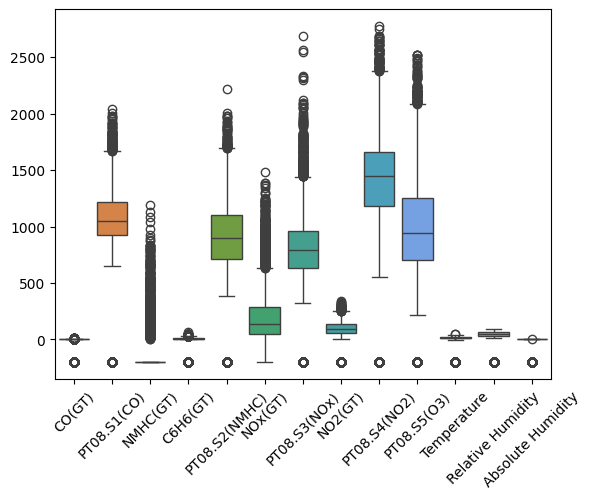

In [24]:
#error correction
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [25]:
def remove_outliers(col):
    Q1=col.quantile(0.25)
    Q3=col.quantile(0.75)
    IQR=Q3-Q1
    threshold=1.5*IQR
    outlier_mask=(col<Q1-threshold) | (col>Q3+threshold)
    return col[~outlier_mask]


In [26]:
df.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'Temperature', 'Relative Humidity', 'Absolute Humidity'],
      dtype='object')

In [27]:
num_cols=df.select_dtypes(include=['number']).columns

In [28]:
for col in num_cols:
    cleaned_col=remove_outliers(df[col])
    df.loc[cleaned_col.index,col]=cleaned_col

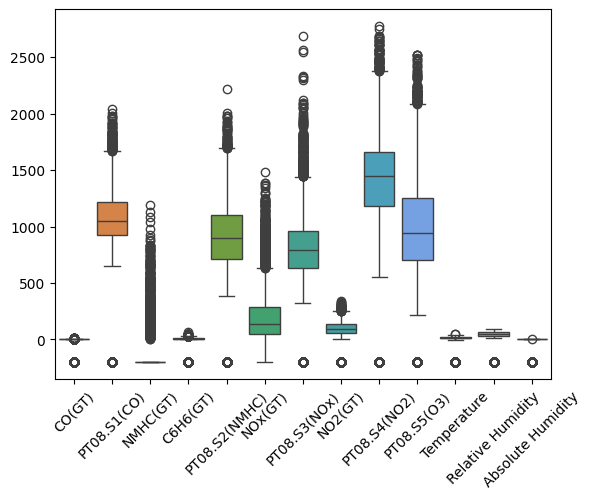

In [29]:
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative Humidity,Absolute Humidity
0,0.956111,0.696429,0.251980,0.803565,0.516156,0.217987,0.435657,0.579630,0.635966,0.539111,0.873262,0.862141,0.992715
1,0.953280,0.666071,0.224622,0.794084,0.478459,0.180465,0.476587,0.540741,0.591261,0.430408,0.872036,0.857984,0.992556
2,0.954224,0.715179,0.207343,0.792567,0.471831,0.197141,0.464794,0.581481,0.589916,0.467866,0.866312,0.879806,0.992678
3,0.954224,0.703571,0.201584,0.793326,0.475559,0.221560,0.448144,0.596296,0.599664,0.515241,0.862633,0.900589,0.992858
4,0.951392,0.657143,0.180706,0.783087,0.429163,0.197141,0.487340,0.585185,0.568067,0.481087,0.863451,0.899203,0.992869


In [31]:
#data model building
y=df['Temperature']
X=df.drop('Temperature',axis=1)


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(X_train,y_train)
y_pred=model1.predict(X_test)

In [34]:
print("r2 score:",r2_score(y_test,y_pred))
print("mean absolute error:",mean_absolute_error(y_test,y_pred))
print("mean squared error:",mean_squared_error(y_test,y_pred))
print("accuracy:",r2_score(y_test,y_pred)*100)

r2 score: 0.995077596394832
mean absolute error: 0.009681121939987306
mean squared error: 0.00015160045647323898
accuracy: 99.5077596394832


In [35]:
from sklearn.tree import DecisionTreeRegressor
model2=DecisionTreeRegressor()
model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)

In [36]:
print("r2 score:",r2_score(y_test,y_pred))
print("mean absolute error:",mean_absolute_error(y_test,y_pred))
print("mean squared error:",mean_squared_error(y_test,y_pred))
print("accuracy:",r2_score(y_test,y_pred)*100)

r2 score: 0.9998836460239227
mean absolute error: 0.001233699184435082
mean squared error: 3.583476143094237e-06
accuracy: 99.98836460239227


In [37]:
from sklearn.ensemble import RandomForestRegressor
model3 = RandomForestRegressor()


In [38]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model3, X, y, cv=5, scoring='r2')
print("Mean R2 from Cross-validation:", scores.mean())

Mean R2 from Cross-validation: 0.9996290082755849


In [39]:
# Example new input (must match the number and order of features in X)
# Replace these example values with actual sensor data
new_data = [[0.95, 0.66, 0.22, 0.79, 0.47, 0.18, 0.47, 0.54, 0.59, 0.43, 0.86, 0.99]]

# Predict using Decision Tree
prediction = model1.predict(new_data)

print("Predicted Temperature for new data:", prediction[0])


Predicted Temperature for new data: 0.8812366513170653


C:\Users\Saibaba\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
# Prepare a dummy input with same shape (13 features) and insert predicted temperature at correct index (10)
dummy_input = [[0]*10 + [prediction[0]] + [0]*2]  # Total 13 features as in original df

# Inverse transform
inverse_result = scaler.inverse_transform(dummy_input)

# Extract the actual temperature value from column index 10
actual_temperature = inverse_result[0][10]

print("Actual Predicted Temperature:", actual_temperature)


Actual Predicted Temperature: 15.550484912154184
